# Request For Change Prediction = Predict if incident is related to a Change Request
### Target ---> RFC_Flag (user defined column)

In [56]:
import pandas as pd
import numpy as np
import vizion as vz

# Load the dataset

In [57]:
df = pd.read_csv("itsm_dataset.csv")

# # Create target Column Before Cleaning

In [58]:
df["RFC_Flag"] = df["Related_Change"].apply(lambda x: 0 if pd.isna(x) or x=="" else 1)
df["RFC_Flag"].value_counts()


RFC_Flag
0    46046
1      560
Name: count, dtype: int64

In [59]:
# The previous file code for cleaning

cc=['No_of_Related_Incidents', 'No_of_Related_Changes', 'Reopen_Time']
df.drop(cc,axis=1,inplace=True)

mis_col = df.columns[df.isnull().sum() > 0].tolist()

cat_mis_col = df[mis_col].select_dtypes(include=['object'])
num_mis_col = df[mis_col].select_dtypes(include=['int64','float64'])


# for categorical columns
for col in cat_mis_col:
    df.loc[ : , col] = df[col].fillna(df[col].mode()[0])

# for numerical columns
for col in num_mis_col:
    df.loc[ : , col] = df[col].fillna(df[col].median())

df = df.replace([""," ",'nan','Null','NULL','null'],'Unknown')
(df == "Unknown").sum()


df["Closure_Code"] = df["Closure_Code"].replace("Unknown", df["Closure_Code"].mode()[0])

#  invalid value in Impact column: NS
df["Impact"] = df["Impact"].replace("NS",df["Impact"].mode()[0]).astype(int)


df['Urgency'] = df['Urgency'].replace({'5 - Very Low':5}).astype(int)

df['Urgency'].value_counts()


df['Close_Time']    =  pd.to_datetime(df['Close_Time'], format='%d-%m-%Y %H:%M',errors='coerce')
df['Open_Time'] =   pd.to_datetime(df['Open_Time'], format='%d-%m-%Y %H:%M',errors='coerce')
df.drop("Handle_Time_hrs",axis=1,inplace=True)

df["Handle_Time_hrs"] = (df["Close_Time"] - df["Open_Time"]).dt.total_seconds() / 3600


In [60]:
df.columns


Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Resolved_Time',
       'Close_Time', 'Closure_Code', 'No_of_Related_Interactions',
       'Related_Interaction', 'Related_Change', 'RFC_Flag', 'Handle_Time_hrs'],
      dtype='object')

In [61]:
# df["RFC_Flag"] = df["Related_Change"].apply(lambda x: 0 if pd.isna(x) or x=="" else 1)
# df["RFC_Flag"].value_counts()


This converts Related_Change into binary target.

# Removing Leakage columns

In [62]:
drop_cols = [
    "Related_Change",
    "No_of_Related_Changes",
    "Resolved_Time",
    "Close_Time",
    "Closure_Code",
    "Alert_Status",
    "Status",
    "Incident_ID",
    "KB_number",
    "WBS",
    "Related_Interaction",
    "No_of_Related_Interactions",
    "number_cnt"
]

df.drop(columns=drop_cols, inplace=True, errors='ignore')


## data cleaned Sucessfully

In [63]:
df.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'Impact', 'Urgency', 'Priority',
       'Category', 'No_of_Reassignments', 'Open_Time', 'RFC_Flag',
       'Handle_Time_hrs'],
      dtype='object')

In [64]:
df["hour"] = df["Open_Time"].dt.hour
df["day"] = df["Open_Time"].dt.day
df["month"] = df["Open_Time"].dt.month
df["weekday"] = df["Open_Time"].dt.weekday
df["quarter"] = df["Open_Time"].dt.quarter


# Outliers

📦 Backup created as variable 'bkp'
🧮 Processing 2 columns (Skipped 0)


📊 Column: Handle_Time_hrs
   Skew: 12.65, Outliers: 2959 (6.35%)
   Method used: REMOVE, Threshold: 3

📊 Column: No_of_Reassignments
   Skew: 3.33, Outliers: 1675 (3.84%)
   Method used: REMOVE, Threshold: 3


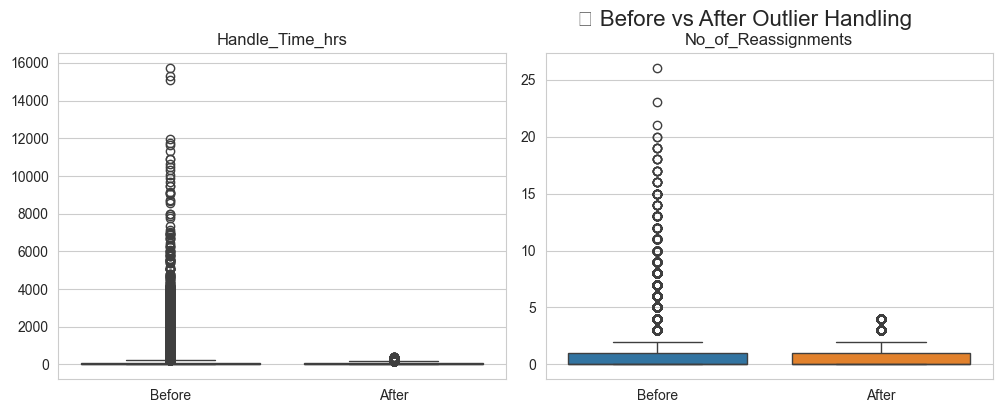


✅ Outlier handling complete!
Final dataset shape: (41972, 16)


,CI_Name,CI_Cat,CI_Subcat,Impact,Urgency,Priority,Category,No_of_Reassignments,Open_Time,RFC_Flag,Handle_Time_hrs,hour,day,month,weekday,quarter
454,SUB000533,subapplication,Web Based Application,4,4,4.0,incident,3.0,2013-09-17 12:09:00,0,335.066667,12,17,9,1,3
460,SBA000263,application,Server Based Application,5,5,5.0,request for information,4.0,2013-09-17 15:27:00,0,356.166667,15,17,9,1,3
461,LAP000523,computer,Laptop,5,5,5.0,incident,2.0,2013-09-17 13:15:00,0,331.650000,13,17,9,1,3
462,SBA000263,application,Server Based Application,5,5,5.0,request for information,3.0,2013-09-17 13:41:00,0,355.066667,13,17,9,1,3
467,SBA000101,application,Server Based Application,5,5,5.0,request for information,3.0,2013-09-17 17:07:00,0,358.316667,17,17,9,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46601,SBA000464,application,Server Based Application,4,4,4.0,incident,0.0,2014-03-31 16:23:00,0,0.100000,16,31,3,0,1
46602,SBA000461,application,Server Based Application,4,4,4.0,incident,0.0,2014-03-31 15:03:00,0,0.433333,15,31,3,0,1
46603,LAP000019,computer,Laptop,5,5,5.0,incident,0.0,2014-03-31 15:28:00,0,0.066667,15,31,3,0,1
46604,WBA000058,application,Web Based Application,4,4,4.0,incident,0.0,2014-03-31 15:35:00,0,0.116667,15,31,3,0,1


In [65]:
vz.handle_outliers(df,['Handle_Time_hrs', 'No_of_Reassignments'])


# data is ready to Encode + Train Test Split + Model Training

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CI_Name              46606 non-null  object        
 1   CI_Cat               46606 non-null  object        
 2   CI_Subcat            46606 non-null  object        
 3   Impact               46606 non-null  int64         
 4   Urgency              46606 non-null  int64         
 5   Priority             46606 non-null  float64       
 6   Category             46606 non-null  object        
 7   No_of_Reassignments  46606 non-null  float64       
 8   Open_Time            46606 non-null  datetime64[ns]
 9   RFC_Flag             46606 non-null  int64         
 10  Handle_Time_hrs      46606 non-null  float64       
 11  hour                 46606 non-null  int32         
 12  day                  46606 non-null  int32         
 13  month                46606 non-

# identify columns

In [67]:
cat_cols = ['CI_Name', 'CI_Cat', 'CI_Subcat', 'Category']
num_cols = [
    'Impact','Urgency','Priority',
    'No_of_Reassignments','Handle_Time_hrs',
    'hour','day','month','weekday','quarter'
]
target = 'RFC_Flag'


# split data before encoding

In [68]:
from sklearn.model_selection import train_test_split

X = df[cat_cols + num_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
y.value_counts()

RFC_Flag
0    46046
1      560
Name: count, dtype: int64

# encoding for categorical column

In [69]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [70]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)


# Random Forest Pipeline

In [71]:
from sklearn.ensemble import RandomForestClassifier

rf_Pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42 
    ))
])

rf_Pipeline.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# PREDICTION and evaluation

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      9210
           1       0.83      0.36      0.50       112

    accuracy                           0.99      9322
   macro avg       0.91      0.68      0.75      9322
weighted avg       0.99      0.99      0.99      9322



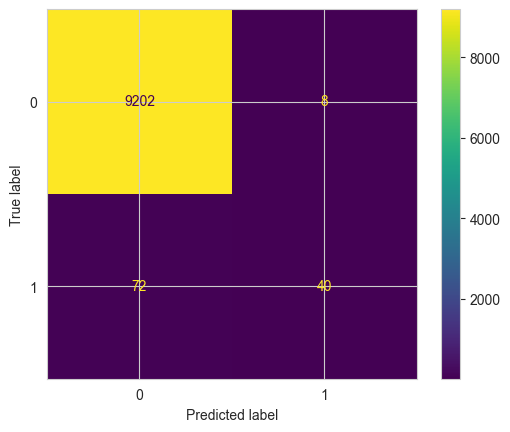

In [72]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
y_pred = rf_Pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(rf_Pipeline, X_test, y_test)




# XGBoost Pipeline

In [73]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
# from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

xg_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', 
     XGBClassifier(
        eval_metric='logloss',
        scale_pos_weight=(len(y_train) / y_train.sum()),  # important
        max_depth=5,
        learning_rate=0.1,
        n_estimators=200
    )
     )
])

xg_pipeline.fit(X_train, y_train)
y_pred = xg_pipeline.predict(X_test)


In [74]:
xg_pipeline.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [75]:
y_pred = xg_pipeline.predict(X_test)


              precision    recall  f1-score   support

           0       1.00      0.78      0.88      9210
           1       0.04      0.79      0.08       112

    accuracy                           0.78      9322
   macro avg       0.52      0.78      0.48      9322
weighted avg       0.99      0.78      0.87      9322



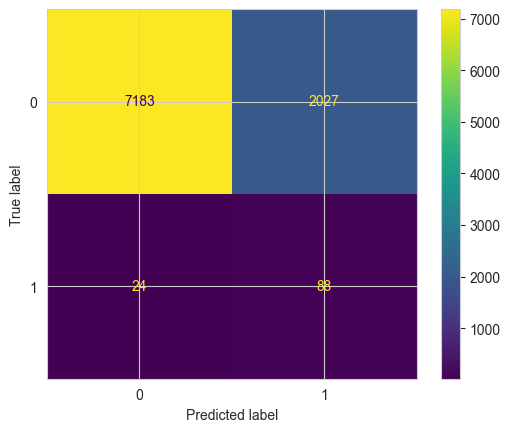

In [76]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(xg_pipeline, X_test, y_test)


## XGBoost is better for this problem.
### XGBoost achieved very high recall (0.79) for RFC cases, meaning it successfully detects most change-related incidents.
### It sacrifices precision (0.04) but ensures fewer critical RFC incidents are missed, which matches the ITSM business goal.
### RandomForest gives high precision (0.83) but very low recall (0.36), meaning it misses many true RFC incidents.
### XGBoost is preferred because detecting RFC failures is more important than avoiding false alarms.

In [77]:
import joblib

joblib.dump(xg_pipeline,"Xgboost_RFC.pkl")

['Xgboost_RFC.pkl']